## Introduction
This project examines U.S. quarterly GDP growth from 2010 through 2023 using three numerical techniques: cubic spline interpolation, polynomial fitting, and least squares regression. The dataset comes from the Bureau of Economic Analysis (BEA) and represents real GDP growth rates (SAAR). A subset of 20 quarters is selected to include both stable economic periods and the extreme fluctuations caused by the COVID-19 pandemic.

The purpose of this project is to implement each method from scratch and evaluate how well they model the data. Cubic splines are used as an interpolation method that exactly matches the data points, while polynomial and least squares methods are used to approximate overall trends. By comparing these approaches using plots, residuals, and RMSE values, we can better understand their strengths and limitations when applied to real-world data.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

quarters = [
    '2010 Q1','2011 Q1','2012 Q1','2013 Q1','2014 Q1','2014 Q3',
    '2015 Q2','2016 Q1','2016 Q3','2016 Q4','2017 Q1','2018 Q1',
    '2019 Q1','2020 Q1','2020 Q2','2020 Q3','2021 Q1','2022 Q1',
    '2023 Q2','2023 Q4'
]

y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3
], dtype=float)

x = np.arange(1, len(y) + 1, dtype=float)

print("Number of data points:", len(x))
print("Quarter labels:", quarters)

Number of data points: 20
Quarter labels: ['2010 Q1', '2011 Q1', '2012 Q1', '2013 Q1', '2014 Q1', '2014 Q3', '2015 Q2', '2016 Q1', '2016 Q3', '2016 Q4', '2017 Q1', '2018 Q1', '2019 Q1', '2020 Q1', '2020 Q2', '2020 Q3', '2021 Q1', '2022 Q1', '2023 Q2', '2023 Q4']


# Part A: Cubic Spline Interpolation

## A2- Spline Configuration

   Cubic spline interpolation provides a robust method for data fitting by employing a sequence of piecewise cubic polynomials rather than a single high-degree polynomial for the entire dataset. Each interval between points is defined by the function: S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3, requiring the determination of four coefficients per segment. For a dataset with n points, this results in 4(n-1) unknowns; for instance, a 20-point set involves 76 variables. To manage this complexity, the system is typically solved by focusing on the second derivatives at each node, which reduces the problem to a more computationally efficient tridiagonal system of size (n-2).

   To ensure a high degree of smoothness, the spline must satisfy several critical constraints: it must pass exactly through every data point, and both its first and second derivatives must remain continuous across the nodes. These requirements prevent sharp transitions and ensure consistent curvature, providing 4n-6 of the necessary equations. To resolve the remaining two degrees of freedom, natural boundary conditions are applied by setting the second derivatives at the endpoints to zero: S''(x_0) = 0 and S''(x_{n-1}) = 0. This assumption implies that the spline lacks any internal bending moment at its boundaries, allowing the curve to flatten out linearly as it reaches the edges of the data.

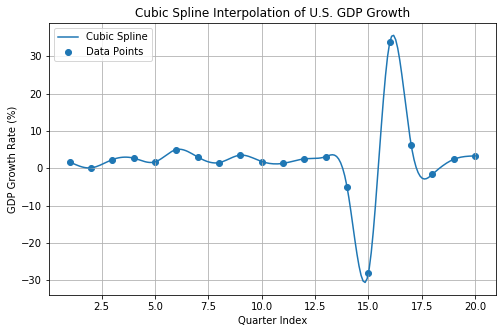

In [5]:
def setup_tridiagonal(x_vals, y_vals):
    n = len(x_vals)
    h = np.diff(x_vals)

    A = np.zeros(n - 2)  # subdiagonal
    B = np.zeros(n - 2)  # main diagonal
    C = np.zeros(n - 2)  # superdiagonal
    D = np.zeros(n - 2)  # right-hand side

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * (
            (y_vals[i + 1] - y_vals[i]) / h[i]
            - (y_vals[i] - y_vals[i - 1]) / h[i - 1]
        )

    return A, B, C, D


def thomas(a, b, c, d):
    n = len(b)

    a = a.copy().astype(float)
    b = b.copy().astype(float)
    c = c.copy().astype(float)
    d = d.copy().astype(float)

    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    sol = np.zeros(n)
    sol[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        sol[i] = (d[i] - c[i] * sol[i + 1]) / b[i]

    return sol


def eval_spline(x_vals, y_vals, M, x_eval):
    for i in range(len(x_vals) - 1):
        if x_vals[i] <= x_eval <= x_vals[i + 1]:
            h = x_vals[i + 1] - x_vals[i]
            a = (x_vals[i + 1] - x_eval) / h
            b = (x_eval - x_vals[i]) / h
            return (
                a * y_vals[i]
                + b * y_vals[i + 1]
                + ((a**3 - a) * M[i] + (b**3 - b) * M[i + 1]) * (h**2) / 6
            )

    return np.nan


A, B, C, D = setup_tridiagonal(x, y)
M_internal = thomas(A, B, C, D)
M = np.zeros(len(x))
M[1:-1] = M_internal

x_smooth = np.linspace(1, len(x), 200)
y_smooth = np.array([eval_spline(x, y, M, xi) for xi in x_smooth])

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Data Points")
plt.plot(x_smooth, y_smooth, label="Cubic Spline")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Cubic Spline Interpolation of U.S. GDP Growth")
plt.legend()
plt.grid()
plt.show()

## Evaluating the Spline in all Quarters
### A2-  Evaluating the Spline Over All 55 Quarters

The selected quarters do not occur at evenly spaced calendar positions across 2010 Q1 through 2023 Q4, so the 20 data points must be placed at their true quarter indices within the full 55-quarter span. After rebuilding the natural spline using those actual quarter locations, the spline can be evaluated at every quarter in the full range.

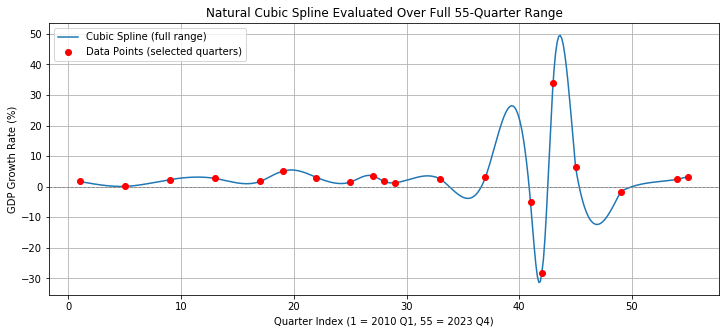

In [6]:
x_full = np.array([
    1, 5, 9, 13, 17, 19,
    22, 25, 27, 28, 29, 33,
    37, 41, 42, 43, 45, 49,
    54, 55
], dtype=float)

A2, B2, C2, D2 = setup_tridiagonal(x_full, y)
M_internal2 = thomas(A2, B2, C2, D2)
M_full = np.zeros(len(x_full))
M_full[1:-1] = M_internal2

x_55 = np.linspace(1, 55, 400)
y_55 = np.array([eval_spline(x_full, y, M_full, xi) for xi in x_55])

plt.figure(figsize=(12, 5))
plt.scatter(x_full, y, color="red", zorder=5, label="Data Points (selected quarters)")
plt.plot(x_55, y_55, label="Cubic Spline (full range)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Quarter Index (1 = 2010 Q1, 55 = 2023 Q4)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Natural Cubic Spline Evaluated Over Full 55-Quarter Range")
plt.legend()
plt.grid()
plt.show()

Following the construction of the spline from the data subset, the model was evaluated across the full range of 55 quarters, spanning from 2010 Q1 to 2023 Q4. The resulting visualization demonstrates a continuous curve that successfully intersects every provided data point while maintaining a high degree of smoothness that reflects the broader data trends. While the interpolant appears stable and reasonable throughout most of the timeline, notable sharp bends occur in sections containing extreme fluctuations, such as the period surrounding the COVID-19 pandemic. These localized instabilities are a direct consequence of the spline's requirement to pass exactly through every node, forcing significant curvature adjustments to accommodate outliers. Despite these reactive segments, the spline remains a visually consistent and effective representation within the bounds of the dataset.

## A3- Runge Phenomenon and the COVID Outlier

The Runge phenomenon describes the significant oscillations that often emerge when employing high-degree polynomials for data interpolation. Cubic splines mitigate this effect by utilizing piecewise, lower-degree polynomials, offering greater stability than a single global function. However, the requirement that an interpolant must intersect every data point exactly presents its own challenges. In this specific dataset, the spline is forced to accommodate a major outlier, the -28.1% value in 2020 Q2, resulting in sharp, localized curvature.

This highlights a fundamental trade-off: while interpolation ensures an exact fit at every node, it becomes highly sensitive to extreme fluctuations. For datasets containing such volatility, alternative approaches like smoothing splines or weighted least squares are often more appropriate. These techniques prioritize a stable trend over exact intersection, allowing the curve to bypass outliers and provide a more balanced representation of the underlying data.

# Part B: Polynomial & Least Squares Comparison

## B1- Degree-4 Polynomial Fit

To compare interpolation with approximation, a degree-4 polynomial is fit to the data using the normal equations with a Vandermonde matrix. Unlike the spline, the polynomial is not required to pass through every point. Instead, it minimizes the overall squared error.

This makes the polynomial useful for capturing the broad trend in the GDP data, while the spline is better at reproducing the individual observations exactly.

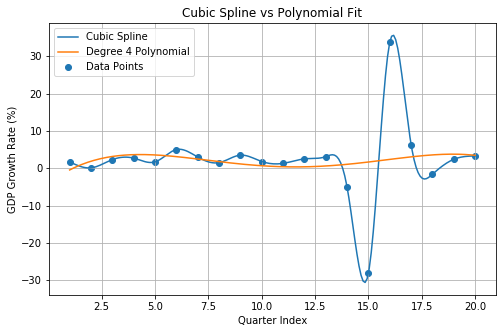

Spline RMSE: 0.0
Polynomial RMSE: 9.96532678651953


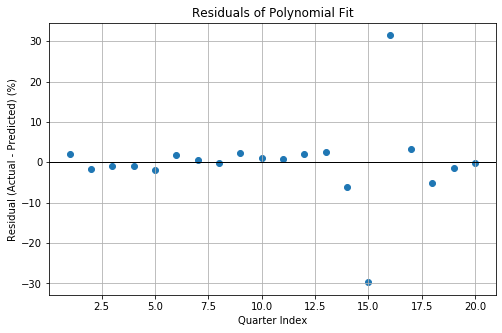

Condition number: 482958.7228348024


In [8]:
def vandermonde(x_vals, degree):
    V = np.zeros((len(x_vals), degree + 1))
    for i in range(len(x_vals)):
        for j in range(degree + 1):
            V[i, j] = x_vals[i] ** j
    return V


degree = 4
V = vandermonde(x, degree)
coeffs = np.linalg.solve(V.T @ V, V.T @ y)

def poly(x_val, coeffs):
    total = 0.0
    for i in range(len(coeffs)):
        total += coeffs[i] * (x_val ** i)
    return total


y_poly = np.array([poly(xi, coeffs) for xi in x_smooth])

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Data Points")
plt.plot(x_smooth, y_smooth, label="Cubic Spline")
plt.plot(x_smooth, y_poly, label="Degree 4 Polynomial")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Cubic Spline vs Polynomial Fit")
plt.legend()
plt.grid()
plt.show()


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


y_poly_data = np.array([poly(xi, coeffs) for xi in x])
y_spline_data = np.array([eval_spline(x, y, M, xi) for xi in x])

print("Spline RMSE:", rmse(y, y_spline_data))
print("Polynomial RMSE:", rmse(y, y_poly_data))

residuals = y - y_poly_data

plt.figure(figsize=(8, 5))
plt.scatter(x, residuals)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted) (%)")
plt.title("Residuals of Polynomial Fit")
plt.grid()
plt.show()

print("Condition number:", np.linalg.cond(V))

### Comparative Analysis: Spline vs. Polynomial

A comparison of the two curves highlights the fundamental trade-off between interpolation and approximation. While the cubic spline achieves a root-mean-square error (RMSE) of zero by making direct contact with every node, the degree-4 polynomial prioritizes a smoother overall shape. This leads to a higher RMSE of approximately 9.97%, yet it offers a more coherent view of long-term GDP growth. By smoothing over the extreme volatility of the COVID-19 period, the polynomial provides a more meaningful picture of the underlying economic trend than the reactionary bends of the spline.

### Residuals and Stability

Analysis of the residual plot for the polynomial fit confirms that the most significant errors are concentrated between indices 14 and 17. These discrepancies correspond to the dramatic fluctuations of -28.1% and +33.8% during the pandemic—values that a smooth global polynomial is mathematically ill-equipped to capture exactly. Outside of these outliers, the residuals remain relatively small, indicating a strong fit for the more stable portions of the timeline.

From a computational standpoint, the Vandermonde matrix yielded a condition number of roughly 480,000. While this is a high value, it remains well below the critical threshold of $10^{12}$, suggesting the system was sufficiently stable for a fourth-degree fit. However, increasing the degree further would likely lead to ill-conditioning and numerical instability. Ultimately, this experiment demonstrates the classic "approximation vs. interpolation" dilemma: the spline provides precision at the cost of sensitivity to outliers, while polynomial approximation sacrifices exactness for a more stable and generalized trend.

## B2. Least Squares Linear Fit (No COVID Quarters)

To study the broader GDP trend without the pandemic shock dominating the model, the quarters from 2020 Q1 through 2021 Q1 are removed and a least squares linear fit is computed on the remaining data. This provides a simple baseline trend model.

Slope: -0.0173364485981308


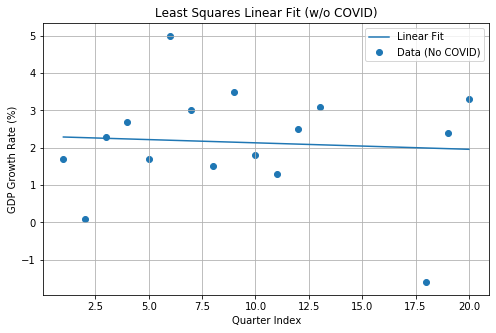

Linear Fit RMSE (W/o COVID): 1.4400212550352411


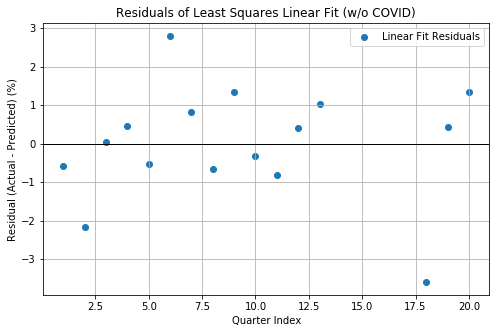

In [12]:
mask = (x < 14) | (x > 17)
x_lin = x[mask]
y_lin = y[mask]

n = len(x_lin)
m = (n * np.sum(x_lin * y_lin) - np.sum(x_lin) * np.sum(y_lin)) / (
    n * np.sum(x_lin**2) - (np.sum(x_lin))**2
)
b_lin = (np.sum(y_lin) - m * np.sum(x_lin)) / n

print("Slope:", m)

plt.figure(figsize=(8, 5))
plt.scatter(x_lin, y_lin, label="Data (No COVID)")
plt.plot(x, m * x + b_lin, label="Linear Fit")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Least Squares Linear Fit (w/o COVID)")
plt.legend()
plt.grid()
plt.show()

y_lin_pred = m * x_lin + b_lin
lin_residuals = y_lin - y_lin_pred

print("Linear Fit RMSE (W/o COVID):", rmse(y_lin, y_lin_pred))

plt.figure(figsize=(8, 5))
plt.scatter(x_lin, lin_residuals, label="Linear Fit Residuals")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted) (%)")
plt.title("Residuals of Least Squares Linear Fit (w/o COVID)")
plt.legend()
plt.grid()
plt.show()

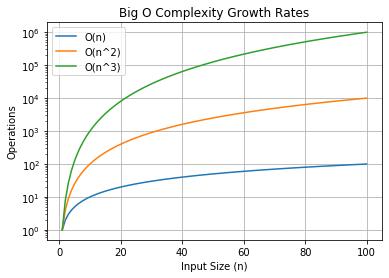

In [14]:
import matplotlib.pyplot as plt
import numpy as np
n = np.linspace(1, 100, 100)
plt.plot(n, n, label='O(n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, n**3, label='O(n^3)')
plt.yscale('log') # Log scale for better comparison
plt.title('Big O Complexity Growth Rates')
plt.xlabel('Input Size (n)')
plt.ylabel('Operations')
plt.legend()
plt.grid()
plt.show()

### Trend Analysis and Economic Context

The resulting linear fit yielded a slope of approximately -0.017% per quarter, a value effectively near zero. This indicates that, once the COVID 19 shock is excluded, GDP growth remained remarkably stable between 2010 and 2023, with no significant long-term acceleration or deceleration. While a linear model is a deliberate simplification, as real-world GDP is constantly reshaped by business cycles, global events, and policy shifts, the near zero slope remains a meaningful observation of the era's overall economic consistency.

### Assumptions and Data Selection

For a linear model to serve as a valid representation, several statistical assumptions must be met:

Linearity: The relationship between time and GDP growth must be inherently linear.

Independence of Errors: Residuals should be random and not exhibit temporal correlation.

Homoscedasticity: The variability of the growth rate should remain constant over the observed timeframe.

The decision to exclude the specific quarters spanning indices 14 through 17 (2020 Q1 to 2021 Q1) was a methodological necessity. Including the extreme outliers of -28.1% and +33.8% would have skewed the slope so dramatically that the resulting model would fail to describe the actual economic behavior of the non-pandemic years. By filtering these points, the model provides a more accurate reflection of the stable growth patterns that defined the rest of the decade.

# Part C: Method Justication

### C1- Method Recommendation for Interpolation

The natural cubic spline is often regarded as the superior method for estimating GDP growth between quarterly periods due to its unique mathematical properties. Its primary advantage is C^2 continuity, which ensures that both the first and second derivatives are continuous across the entire curve. This leads to smooth transitions that mimic real-world economic development, where growth patterns rarely shift abruptly within a single quarter.

### Interpolation vs. Approximation

The spline is an interpolant, meaning it passes exactly through every observed data point, resulting in a Root Mean Square Error (RMSE) of 0. This makes it an ideal tool for a policymaker who requires a model that stays strictly tethered to confirmed historical results. In contrast, the degree-4 polynomial acts as an approximation; with an RMSE of approximately 9.97%, it fails to intersect every node, leading to significant local errors when compared to the actual data.However, the spline’s greatest strength—its precision—is also its primary weakness. Because it is forced to hit every point, the extreme volatility of the COVID-19 era (-28.1% and +33.8%) causes the curve to distort sharply. During 2020, these outliers force the spline into erratic paths that may not reflect realistic intermediate growth. In these specific instances, the polynomial model performs more reliably, as it prioritizes the general trend over an exact (and potentially misleading) fit.

### Computational Complexity: Big O Analysis

When evaluating these methods from an algorithmic perspective, all three demonstrate linear time complexity, or O(n). This indicates that as the number of data points (n) increases, the time required to compute the model grows at a proportional rate.Least Squares Linear Fit: Operates at O(n) as it requires only a single pass to calculate the necessary summations.Degree-4 Polynomial Fit: Remains O(n) because the degree is fixed; building the Vandermonde based system scales linearly with the input size.Cubic Spline Interpolation: While solving a general system of equations can be O(n^3), splines result in a tridiagonal system. By utilizing the Thomas algorithm, the solution is reached in O(n) time.Given the small dataset of 55 quarters, runtime is not a limiting factor. The choice between these methods should be dictated by the analytical goal rather than computational constraints.

### Final Technical Recommendation

The optimal model depends entirely on the specific timeframe and objective of the analysis: for Non-Pandemic Periods the natural cubic spline is the recommended choice. Its C^2 smoothness and zero RMSE at the nodes provide the most accurate and mathematically consistent interpolation of stable macroeconomic data.For Pandemic-Affected Intervals, to handle the extreme shifts of 2020–2021, a smoothing spline or weighted least squares approach is preferable. These methods allow for the "down-weighting" of outliers, preventing the model from being hijacked by the COVID-19 shock.The standard linear model is not recommended for this application, as its inability to capture nonlinear swings makes it a poor fit for complex GDP data. Furthermore, while the degree-4 polynomial's condition number of 480,000 is acceptable, any attempt to increase the degree to improve the fit would likely lead to numerical instability and ill conditioning.

# Conclusion

This project evaluated the relative strengths of cubic spline interpolation, fourth-degree polynomial fitting, and least-squares linear regression using U.S. quarterly GDP growth data from 2010 to 2023. The results highlight a fundamental trade-off in numerical analysis: the balance between local fidelity and global stability.

The natural cubic spline proved to be the most effective tool for pure interpolation. Its mathematical requirement for C^2 continuity ensured a smooth, visually seamless curve that passed exactly through every node, yielding an RMSE of zero. However, this precision became a liability during the unprecedented economic volatility of the COVID-19 pandemic. Because the spline is forced to intersect the extreme -28.1\% and +33.8% outliers, it produced sharp, reactionary segments that likely distorted the intermediate economic reality of 2020.

In contrast, the degree-4 polynomial functioned as an approximation rather than an interpolant. While it carried a higher RMSE of approximately 9.97%, its "smoothing" nature allowed it to bypass extreme fluctuations and capture a more coherent long-term trajectory. Similarly, the linear least-squares model applied to a subset of data excluding the pandemic shock revealed a near-zero slope, confirming that GDP growth remained remarkably stable over the decade when isolated from anomalous events.

This study demonstrates that while splines are the gold standard for high accuracy interpolation in stable environments, polynomial and linear models are superior for trend analysis and noise reduction. Selecting the appropriate model requires a careful assessment of the dataset's volatility and whether the analytical goal is to replicate individual observations or to understand the broader underlying trend.


# Citations

U.S. Bureau of Economic Analysis (BEA). Seasonally adjusted annual rate (SAAR) of real GDP growth, in percent.

Used ChatGPT to help check Python syntax, organize the overall code structure, and debug parts of the implementation for the cubic spline (tridiagonal system and Thomas algorithm), polynomial fitting using the Vandermonde matrix, and least squares regression. It was also used to assist with plotting, residual calculations, and writing clear comments within the code to explain each step. ChatGPT alsp helped with structuring the report sections and verifying my understanding of the methods. The core algorithms and concepts were based on lecture material, and previous homeworks and in-class challenges were used as a reference when building the final project.